## Decision Tree and Random Forest
In this laboratory, we will explore two powerful and widely used machine learning techniques: Decision Trees and Random Forests. These models are foundational in supervised learning and have broad applications, from classification and regression to feature selection and ensemble learning.

The primary objective of this laboratory is to gain a deep understanding of how these models work by implementing them from scratch. Rather than relying on existing machine learning libraries, we will develop the core algorithms step-by-step.

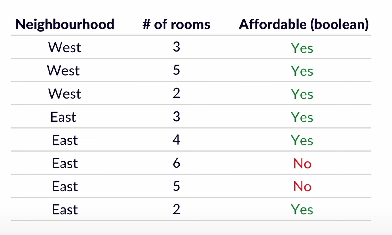
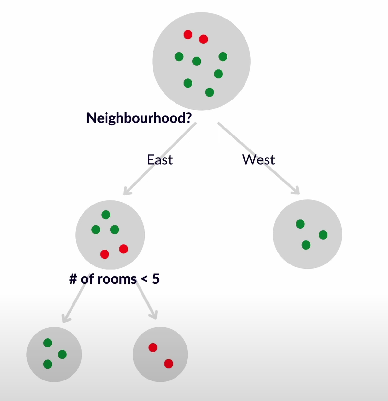

1. Based on what do we choose the spliting feature?

2. How do I choose the split point (5 for the number of rooms)?

3. When to stop splitting?

Information gain and Entropy
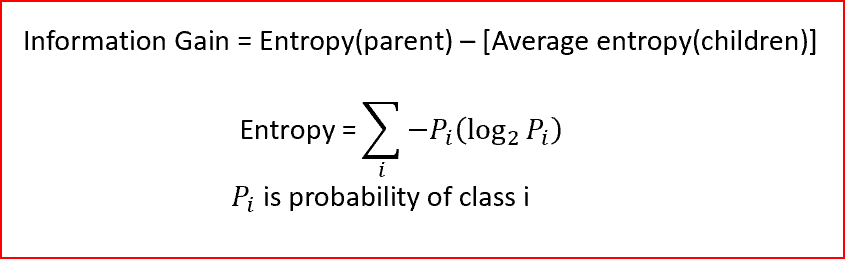
Stopping criteria: maximum depth, minimum number of samples



Steps of the algorithm:
1. Calculate information gain with each possible split
2. Divide set with that feature and value that gives the most information gain
3. Divede tree and do the same for all created branches until a stopping criteria is reached

## How do we test a given data point with our decision tree?
To determine the prediction for a given data point, we traverse the decision tree starting from the root node and following the appropriate branches based on the feature values. This process continues until we reach a leaf node. If the leaf node represents a specific class, we return that class as the prediction. Otherwise, we return the majority class from the leaf node.

## Node Class implementation details

The Node class represents a single node in the decision tree.

feature: The feature index used for splitting at this node

threshold: The threshold value for splitting the data

children: References to the child nodes

value: The predicted class if this is a leaf node

is_leaf_node(): Checks if the node is a leaf node by determining if the value attribute is set.

In [1]:
import numpy as np
import pandas as pd
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, children=None, value=None, default_val=None):
        self.feature = feature
        self.threshold = threshold
        self.children = children if children is not None else {}
        self.value = value
        self.default_val = default_val
        
    def is_leaf_node(self):
        return self.value is not None


## Decision Tree implementation details

Parameters:

min_samples_split: The minimum number of samples required to split a node. This prevents overfitting by stopping the tree from growing too deeply on small datasets

max_depth: The maximum depth of the tree. This also helps prevent overfitting by limiting the tree size

n_features: The number of features to consider for splitting at each node. If not specified, the default is to use all features

root: Initially set to None, this will hold the root node of the constructed tree after training

In [2]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=10, min_gain=1e-7):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.min_gain = min_gain
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        unique_labels, counts = np.unique(y, return_counts=True)
        most_common = unique_labels[np.argmax(counts)]

        # check stopping criteria
        if (depth >= self.max_depth or len(unique_labels) == 1 or n_samples < self.min_samples_split):
            return Node(value=most_common)

        # find the best split
        best_feat, best_thresh, best_gain = self._get_best_split(X, y)

        # stop
        if best_feat is None or best_gain < self.min_gain:
            return Node(value=most_common)

        children = {}
        # handle numeric vs categorical splitting
        if best_thresh is not None:
            # binary bplit(numerical)
            left_idxs = np.where(X[:, best_feat].astype(float) <= best_thresh)[0]
            right_idxs = np.where(X[:, best_feat].astype(float) > best_thresh)[0]
            
            if len(left_idxs) == 0 or len(right_idxs) == 0:
                return Node(value=most_common)
                
            children["left"] = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
            children["right"] = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        else:
            # multiway split (categorical)
            unique_vals = np.unique(X[:, best_feat])
            for val in unique_vals:
                idxs = np.where(X[:, best_feat] == val)[0]
                children[val] = self._grow_tree(X[idxs, :], y[idxs], depth + 1)

        return Node(feature=best_feat, threshold=best_thresh, children=children, default_val=most_common)

    def _get_best_split(self, X, y):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in range(X.shape[1]):
            col = X[:, feat_idx]
            
            is_numeric = False
            try:
                float(col[0])
                is_numeric = True
            except (ValueError, TypeError):
                is_numeric = False

            if is_numeric:
                sorted_unique = np.sort(np.unique(col.astype(float)))
                thresholds = (sorted_unique[:-1] + sorted_unique[1:]) / 2
                for thr in thresholds:
                    gain = self._info_gain(y, col.astype(float), thr)
                    if gain > best_gain:
                        best_gain, split_idx, split_thresh = gain, feat_idx, thr
            else:
                gain = self._info_gain(y, col, None)
                if gain > best_gain:
                    best_gain, split_idx, split_thresh = gain, feat_idx, None

        return split_idx, split_thresh, best_gain

    def _info_gain(self, y, col, thr):
        parent_entropy = self._entropy(y)
        n = len(y)
        
        if thr is not None:
            left_i = np.where(col <= thr)[0]
            right_i = np.where(col > thr)[0]
            if len(left_i) == 0 or len(right_i) == 0: return 0
            child_ent = (len(left_i)/n)*self._entropy(y[left_i]) + (len(right_i)/n)*self._entropy(y[right_i])
        else:
            unique_vals = np.unique(col)
            child_ent = 0
            for v in unique_vals:
                idxs = np.where(col == v)[0]
                child_ent += (len(idxs)/n) * self._entropy(y[idxs])
                
        return parent_entropy - child_ent

    def _entropy(self, y):
        _, counts = np.unique(y, return_counts=True)
        ps = counts / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        if node.is_leaf_node():
            return node.value

        val = x[node.feature]
        
        if node.threshold is not None:
            branch = "left" if float(val) <= node.threshold else "right"
            return self._traverse(x, node.children[branch])
        else:
            if val in node.children:
                return self._traverse(x, node.children[val])
            return node.default_val

## Dataset used for testing 
### TODO 0) test on the Iris dataset from: https://scikit-learn.org/1.5/datasets/toy_dataset.html

In [3]:
# TODO

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTree(max_depth=5, min_samples_split=2)

print("Training decision tree...")
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Predictions: {predictions}")
print(f"Actual Labels: {y_test}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Training decision tree...
Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual Labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 100.00%


### TODO 1) Implement the accuracy method and test the decision tree model on "digits" dataset from the link above

In [5]:
def accuracy(y_true, y_pred):
    # TODO
    return np.sum(y_true == y_pred) / len(y_true)

In [6]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

data = datasets.load_digits()
X = data.data
y = data.target

# TODO
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTree(max_depth=10, min_samples_split=2)

print("Training decision tree...")
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

acc =  accuracy(y_test, predictions)
print(acc)

Training decision tree...
0.8777777777777778


## Random Forest implementation details
Parameters:

n_trees: The number of decision trees in the forest

max_depth: The maximum depth allowed for each decision tree

min_samples_split: The minimum number of samples required to split a node in each tree

n_features: The number of features to consider for splitting in each tree 

trees: A list to hold the individual DecisionTree instances created during training

### TODO 2) Implement the missing methods in order to complete the implementation for RandomForest


In [7]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, n_feature=None):
        self.n_trees = n_trees
        self.max_depth=max_depth
        self.min_samples_split=min_samples_split
        self.n_features=n_feature
        self.trees = []

    def fit(self, X, y):
        
        """
        Initialize the trees list to store trained decision trees.
        For each tree:
            1 Create a new DecisionTree instance with the specified parameters 
            2 Generate a bootstrap sample of the dataset using the _bootstrap_samples method
            3 Train the decision tree on the bootstrap sample
            4 Append the trained tree to the trees list
        """
        
        # TODO

        self.trees = []
        for _ in range(self.n_trees):
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    # generate a bootstrap sample of the dataset by randomly sampling with replacement
    def _bootstrap_samples(self, X, y):
        """
        Determine the number of samples in the dataset. Choose a random number, n_samples, smaller or equal to the number of samples in the dataset
        Use np.random.choice to randomly sample n_samples indices with replacement (replace=True)
        Return the sampled feature matrix and corresponding labels 
        """
        # TODO

        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]

    #  identifies the majority class in a set of predictions
    def _most_common_label(self, y):
        """
        Use Counter from the collections module to count the occurrences of each label
        Return the most frequent label
        """
        # TODO

        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(predictions, 0, 1)
        predictions = np.array([self._most_common_label(pred) for pred in tree_preds])
        return predictions

In [8]:
# TODO - test the RandomForest model on the same data as before

clf = RandomForest(n_trees=20, max_depth=10)

print("Training Random Forest...")
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

acc =  accuracy(y_test, predictions)
print(acc)

Training Random Forest...
0.95


## TODO 3) Test 5 values for n_trees and plot the obtained values for accuracy. 

Starting tests...
Trees: 1 -> Accuracy: 83.06%
Trees: 5 -> Accuracy: 95.56%
Trees: 10 -> Accuracy: 95.28%
Trees: 20 -> Accuracy: 95.56%
Trees: 50 -> Accuracy: 96.39%


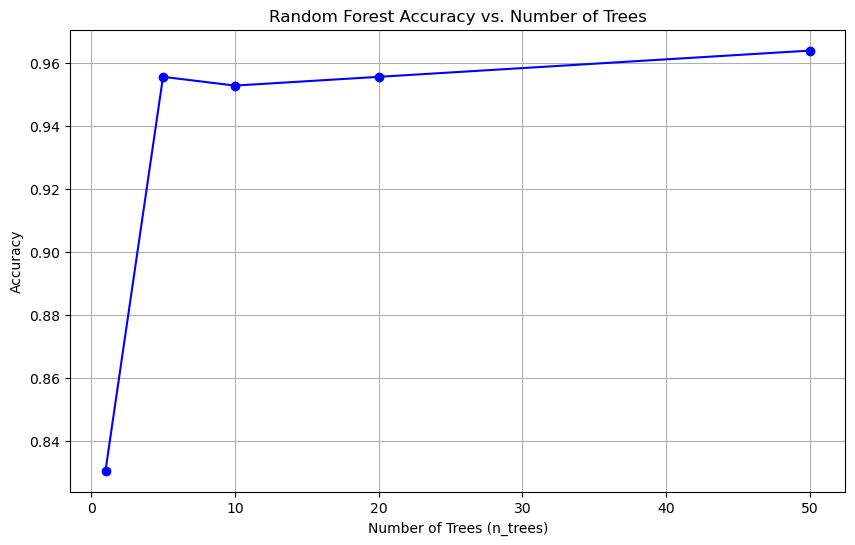

In [9]:
#TODO

import matplotlib.pyplot as plt

n_trees_values = [1, 5, 10, 20, 50]
accuracies = []

print("Starting tests...")

for n in n_trees_values:
    clf = RandomForest(n_trees=n, max_depth=10)
    
    clf.fit(X_train, y_train)
    
    predictions = clf.predict(X_test)
    
    acc = accuracy(y_test, predictions)
    accuracies.append(acc)
    
    print(f"Trees: {n} -> Accuracy: {acc * 100:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(n_trees_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.xlabel('Number of Trees (n_trees)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()
